# Unseen Footage Evaluation

Runs the pipeline on a video the models never trained on, and scores it against
manual annotation.

### What changed from the previous version

**Frame-rate adaptation.** Notebook 12 hardcodes `FPS = 120`. It prints a
warning on other rates and proceeds anyway, which halves every timestamp on a
60 fps clip and makes matching arbitrary. Section 4 makes the pipeline
fps-adaptive: pose is extracted at the video's native rate, then keypoint
**positions** are interpolated onto the 120 fps grid the models were trained on.
Velocity is differenced afterwards, so the models see the units they expect.

**Rally derivation.** The previous version read rallies from the annotation's
`count` field with `(count == 1).cumsum()`. That file numbers counts
continuously across rallies, so `count == 1` matched once and every shot landed
in rally 0. Rallies now come from gaps over 1.5 s, the same rule the pipeline
uses, which makes the comparison fair.

**An alignment gate.** Section 6 refuses to score anything until predicted
timestamps and the annotation occupy the same timeline. That is the check that
would have caught the 2x error immediately.


## 1 · Setup and ground truth

In [2]:
BASE  = "/content/drive/MyDrive/tt_coach"
VIDEO = "test_match2"          # expects raw/external/{VIDEO}.mp4 and _gt.txt

RALLY_GAP_GT = 1.5             # same rule the pipeline uses

from google.colab import drive
drive.mount('/content/drive')

import json, re, textwrap, collections
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import cv2
from sklearn.metrics import classification_report, confusion_matrix, f1_score

BASE = Path(BASE)
EXT  = BASE/"raw/external"
CLASSES = ["serve", "attack", "control", "defence"]
C2I = {c: i for i, c in enumerate(CLASSES)}
GRID_FPS = 120.0               # the rate the models were trained on

mpl.rcParams.update({"figure.dpi": 130, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25,
                     "figure.constrained_layout.use": True})
PAL = {"serve": "#1d4ed8", "attack": "#b91c1c",
       "control": "#065f46", "defence": "#854d0e"}

vid_path = EXT/f"{VIDEO}.mp4"
gt_path  = EXT/f"{VIDEO}_gt.txt"
assert vid_path.exists(), f"missing {vid_path}"
assert gt_path.exists(),  f"missing {gt_path}"

cap = cv2.VideoCapture(str(vid_path))
SRC_FPS = cap.get(cv2.CAP_PROP_FPS)
NFR = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
W   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()
DUR = NFR/SRC_FPS

print(f"video     {W}x{H} @ {SRC_FPS:.2f} fps, {NFR:,} frames, {DUR:.1f} s")
print(f"velocity kinematics: "
      f"{'enabled' if SRC_FPS >= 60 else 'WITHHELD (below 60 fps)'}")
if abs(SRC_FPS - GRID_FPS) > 1:
    print(f"\n  {SRC_FPS:.0f}fps input. Section 4 resamples pose onto the "
          f"{GRID_FPS:.0f}fps grid;")
    print(f"  without that, every timestamp would come out "
          f"{GRID_FPS/SRC_FPS:.2f}x too small.")

# --- parse the timeline ------------------------------------------------------
# "00:03.56 - player (left) - Serve, count 1"
NAME = {"service": "serve", "serve": "serve", "attack": "attack",
        "control": "control", "defense": "defence", "defence": "defence"}
pat = re.compile(r"(\d+):(\d+\.?\d*)\s*-\s*player\s*\((left|right)\)\s*-\s*"
                 r"(\w+)", re.I)

gt = []
for line in gt_path.read_text().splitlines():
    m = pat.search(line)
    if not m:
        continue
    mm, ss, side, cls = m.groups()
    key = cls.lower()
    assert key in NAME, f"unknown class {cls!r} in: {line}"
    gt.append(dict(t=int(mm)*60 + float(ss), player=side.lower(),
                   shot_class=NAME[key]))
gt = pd.DataFrame(gt).sort_values("t").reset_index(drop=True)

# Rallies from GAPS, not from the annotation's count column. That column numbers
# shots continuously across rallies in this file, so (count == 1).cumsum() put
# every shot in rally 0.
gt["rally"] = (gt.t.diff().fillna(0) > RALLY_GAP_GT).cumsum()
gt["shot_index"] = gt.groupby("rally").cumcount()

print(f"\nannotated {len(gt)} shots, {gt.rally.nunique()} rallies, "
      f"{gt.t.min():.2f} to {gt.t.max():.2f} s")
print(gt.shot_class.value_counts().to_string())

Mounted at /content/drive
video     1920x1080 @ 60.00 fps, 2,807 frames, 46.8 s
velocity kinematics: enabled

  60fps input. Section 4 resamples pose onto the 120fps grid;
  without that, every timestamp would come out 2.00x too small.

annotated 35 shots, 8 rallies, 3.56 to 45.32 s
shot_class
control    14
attack     10
serve       8
defence     3


### Sanity checks on the annotation

Three things that would invalidate the comparison if wrong.

In [3]:
ok = True
def check(cond, msg):
    global ok
    print(f"  {'OK  ' if cond else 'FAIL'} {msg}")
    ok &= bool(cond)

check(gt.t.is_monotonic_increasing, "timestamps are ordered")
check(gt.t.max() <= DUR + 1,
      f"last annotation {gt.t.max():.1f}s is inside the {DUR:.1f}s video")

gaps = gt.t.diff().dropna()
within = gaps[gaps <= RALLY_GAP_GT]
check((gaps > 0.2).all(),
      f"no two shots closer than 0.2 s (min gap {gaps.min():.2f}s)")

n_rally = gt.rally.nunique()
mean_len = len(gt)/n_rally
check(2 <= mean_len <= 12,
      f"mean rally length {mean_len:.1f} is plausible (dataset mean 6.8)")

starts = gt[gt.shot_index == 0]
serve_starts = (starts.shot_class == "serve").mean()
check(serve_starts > 0.8,
      f"{serve_starts:.0%} of rallies start with a serve")

print(f"\n  rallies {n_rally}, mean {mean_len:.1f} shots")
print(f"  gaps within rallies: min {within.min():.2f}s  "
      f"median {within.median():.2f}s  max {within.max():.2f}s")
assert ok, "fix the annotation before scoring against it"

  OK   timestamps are ordered
  OK   last annotation 45.3s is inside the 46.8s video
  OK   no two shots closer than 0.2 s (min gap 0.27s)
  OK   mean rally length 4.4 is plausible (dataset mean 6.8)
  OK   100% of rallies start with a serve

  rallies 8, mean 4.4 shots
  gaps within rallies: min 0.27s  median 0.58s  max 0.79s


## 2 · Is the annotation precise enough to score timing?

The paper reports detection at ±8 frames of 120 fps, which is 67 ms. If the
annotation is rounded to coarser than that, detection F1 at 67 ms measures the
annotator, not the model.

In [4]:
frac = np.round(gt.t.values % 1, 3)
cents = np.round(frac*100).astype(int)
gran = "0.01 s" if len(set(cents % 10)) > 3 else ("0.1 s" if len(set(cents)) > 3
                                                  else "coarser than 0.1 s")
print(f"fractional seconds seen: {sorted(set(frac))[:12]}{' ...' if len(set(frac))>12 else ''}")
print(f"apparent granularity: {gran}")

FRAME_MS = 1000/SRC_FPS
print(f"\none source frame = {FRAME_MS:.1f} ms")
if gran == "0.01 s":
    PRECISE = True
    TOL_S = 0.067
    print(f"0.01 s rounding is {10/FRAME_MS:.1f} frames of slack, inside the")
    print(f"paper's 67 ms tolerance. Scoring at 67 ms is defensible.")
else:
    PRECISE = False
    TOL_S = 0.2
    print(f"{gran} rounding exceeds the 67 ms tolerance. Detection will be")
    print(f"scored at {TOL_S*1000:.0f} ms and reported as annotation-limited.")
print(f"\nTOL_S = {TOL_S:.3f} s")

fractional seconds seen: [np.float64(0.01), np.float64(0.02), np.float64(0.03), np.float64(0.05), np.float64(0.17), np.float64(0.22), np.float64(0.23), np.float64(0.29), np.float64(0.31), np.float64(0.32), np.float64(0.37), np.float64(0.38)] ...
apparent granularity: 0.01 s

one source frame = 16.7 ms
0.01 s rounding is 0.6 frames of slack, inside the
paper's 67 ms tolerance. Scoring at 67 ms is defensible.

TOL_S = 0.067 s


## 3 · Load the pipeline

Runs notebook 12's setup cells and stops once `analyse()` exists. One
substitution is made on the way in: the detector stride is a literal `8` frames,
which is 67 ms at 120 fps but 133 ms at 60 fps. It becomes a variable so
Section 4 can scale it to cover the same amount of time.

In [5]:
import json, re, time
from pathlib import Path
from IPython import get_ipython

NB12 = Path("/content/drive/MyDrive/Colab Notebooks/12_pipeline_final.ipynb")
assert NB12.exists(), f"missing {NB12}"

# scaled in section 4; defined first so the substituted source can see it
DET_STRIDE = 8
ACT_STRIDE_BASE = 12

ip = get_ipython()
patched = 0
for c in json.loads(NB12.read_text())["cells"]:
    if c["cell_type"] != "code":
        continue
    src = "".join(c["source"])
    if "di=list(range(0,n,8))" in src:
        src = src.replace("di=list(range(0,n,8))", "di=list(range(0,n,DET_STRIDE))")
        patched += 1
    ip.run_cell(src)
    if re.search(r"^\s*def analyse\(", src, re.M):
        print("\n--- analyse() defined, stopping here ---")
        break

assert "analyse" in dir(), "analyse() not defined"
print(f"detector-stride substitution applied to {patched} cell(s)")
assert patched == 1, "expected exactly one detector-stride site; check nb12"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU: Tesla T4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.8 MB/s eta 0:00:00
onnxruntime-gpu                       1.22.0
rtmlib                                0.0.16
ultralytics                           8.4.157
ultralytics-platform                  0.1.49
ultralytics-thop                      2.1.6

  NOW: Runtime > Restart session, then run from cell 3.
temperature 2.20   rally gap 1.5s
thresholds {'serve': 0.25, 'attack': 0.5, 'control': 1.01, 'defence': 1.01}
suppressed ['control', 'defence']
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 

Downloading: "https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/onnx_sdk/rtmpose-l_simcc-body7_pt-body7_420e-384x288-3f5a1437_20230504.zip" to /root/.cache/rtmlib/hub/checkpoints/rtmpose-l_simcc-body7_pt-body7_420e-384x288-3f5a1437_20230504.zip
100%|██████████| 98.9M/98.9M [00:18<00:00, 5.46MB/s]


load /root/.cache/rtmlib/hub/checkpoints/rtmpose-l_simcc-body7_pt-body7_420e-384x288-3f5a1437_20230504.onnx with onnxruntime backend
detector F1 0.881 | classifier macro-F1 0.792
stages defined
analyse() ready

--- analyse() defined, stopping here ---
detector-stride substitution applied to 1 cell(s)


## 4 · Frame-rate adaptation

Three changes, all reversible and all confined to this cell.

**Decode-side strides scale with the source rate.** The activity gate samples
every 12th frame and the detector every 8th. Those are 100 ms and 67 ms at
120 fps; at 60 fps they must become 6 and 4 to cover the same time.

**Pose is resampled onto the 120 fps grid.** Keypoint *positions* are
interpolated, and velocity is differenced afterwards. The order matters:
computing velocity at 60 fps and rescaling gives a different and wrong answer,
because consecutive-frame displacement spans twice the time.

**Everything downstream stays at 120.** The 97-frame window, the 30-frame NMS
gap and the 1.5 s rally rule all keep their trained meaning. And because a grid
frame index equals `source_frame x 120/source_fps`, dividing by 120 recovers the
true timestamp automatically.

Interpolation restores units, not information. At 60 fps the loss to peak wrist
speed is about 1%, against 54% at 30 fps, so velocity kinematics stay valid
here.

In [6]:
SCALE = GRID_FPS / SRC_FPS
print(f"source {SRC_FPS:.0f} fps -> grid {GRID_FPS:.0f} fps   (scale {SCALE:.3f}x)")

if abs(SCALE - 1.0) < 0.01:
    print("already at the grid rate; no adaptation needed")
else:
    DET_STRIDE  = max(1, round(8  / SCALE))
    ACT_STRIDE  = max(1, round(12 / SCALE))
    print(f"  activity-gate stride  12 -> {ACT_STRIDE}"
          f"  ({ACT_STRIDE/SRC_FPS*1000:.0f} ms, was 100 ms)")
    print(f"  detector stride        8 -> {DET_STRIDE}"
          f"  ({DET_STRIDE/SRC_FPS*1000:.0f} ms, was 67 ms)")


def resample_to_grid(raw, src_fps, grid_fps=GRID_FPS):
    """Native-fps pose -> a grid_fps time base.

    Interpolates POSITIONS and lets velocity be differenced downstream.
    Confidences and detection flags take the nearest source sample, because
    interpolating a confidence would invent certainty that was never measured.
    """
    if abs(src_fps - grid_fps) < 0.5:
        out = dict(raw)
        out["src_frame"] = raw["frame_idx"].astype(np.float32)
        return out

    r = grid_fps / src_fps
    F_src, seg = raw["frame_idx"].astype(int), raw["seg_id"].astype(int)
    KP = raw["keypoints"].astype(np.float32)
    SC = raw["scores"].astype(np.float32)
    BX = raw["boxes"].astype(np.float32)
    DT = raw["detected"]

    oF, oS, oKP, oSC, oBX, oDT, oSRC = [], [], [], [], [], [], []
    for s in np.unique(seg):
        m = seg == s
        f = F_src[m].astype(np.float64)
        if len(f) < 2:
            continue
        g = np.arange(round(f[0]*r), round(f[-1]*r) + 1)
        src_pos = g / r

        nk = np.zeros((len(g), 2, 17, 2), np.float32)
        nb = np.zeros((len(g), 2, 4), np.float32)
        for pi in (0, 1):
            for j in range(17):
                for c in (0, 1):
                    nk[:, pi, j, c] = np.interp(src_pos, f, KP[m][:, pi, j, c])
            for c in range(4):
                nb[:, pi, c] = np.interp(src_pos, f, BX[m][:, pi, c])

        near = np.clip(np.searchsorted(f, src_pos), 0, len(f) - 1)
        oF.append(g.astype(np.int32))
        oS.append(np.full(len(g), s, np.int32))
        oKP.append(nk); oSC.append(SC[m][near]); oBX.append(nb)
        oDT.append(DT[m][near]); oSRC.append(src_pos.astype(np.float32))

    return dict(frame_idx=np.concatenate(oF), seg_id=np.concatenate(oS),
                keypoints=np.concatenate(oKP), scores=np.concatenate(oSC),
                boxes=np.concatenate(oBX), detected=np.concatenate(oDT),
                src_frame=np.concatenate(oSRC))


# --- wrap the two decode-side stages ----------------------------------------
_orig_gate    = activity_gate
_orig_extract = extract_pose

def activity_gate(path, nfr, mid_x):
    """FPS is used here only as int(ACT_PAD_S*FPS); it must be the SOURCE rate
    so the pad covers 0.75 s of real time."""
    global FPS, ACT_STRIDE
    keep_fps = FPS
    FPS = SRC_FPS
    try:
        return _orig_gate(path, nfr, mid_x)
    finally:
        FPS = keep_fps

def extract_pose(path, spans):
    raw = _orig_extract(path, spans)
    n_in = len(raw["frame_idx"])
    out = resample_to_grid(raw, SRC_FPS)
    print(f"  [2b] resampled {n_in:,} -> {len(out['frame_idx']):,} frames "
          f"on the {GRID_FPS:.0f}fps grid")
    return out

FPS = GRID_FPS      # downstream operates on the grid
print(f"\nFPS for downstream stages: {FPS:.0f}")
print("wrapped: activity_gate (source-rate pad), extract_pose (resample)")

source 60 fps -> grid 120 fps   (scale 2.000x)
  activity-gate stride  12 -> 6  (100 ms, was 100 ms)
  detector stride        8 -> 4  (67 ms, was 67 ms)

FPS for downstream stages: 120
wrapped: activity_gate (source-rate pad), extract_pose (resample)


## 5 · Run

`force=True` because any cached `pose_raw.npz` from an earlier run holds
un-resampled source-rate pose.

In [7]:
VIDEO_PATH = str(vid_path)
VIDEO_ID   = VIDEO

t0 = time.time()
pred, rt = analyse(VIDEO_PATH, video_id=VIDEO_ID, force=True)
el = time.time() - t0

print(f"\n{len(pred)} shots in {el/60:.1f} min ({DUR/el:.2f}x realtime)")
print(pred.shot_class.value_counts().to_string())

  copying video to local disk ...
test_match2: 2,807 frames @ 60fps = 0.8 min
  !! 60fps — the pipeline is calibrated for 120fps. Windows, velocities and NMS will not mean what they should.


  gate:   0%|          | 0/2807 [00:00<?, ?it/s]

  [1] gate  20s -> 3 regions, 98% active


  pose:   0%|          | 0/2755 [00:00<?, ?it/s]

  [2b] resampled 2,755 -> 5,507 frames on the 120fps grid
  [2] pose  116s -> 5,507 frames
  [3] canonicalised
  [4] contacts: 35
  [5] sides: 18 left / 17 right
  [6] classified (T=2.20)
  [7] kinematics + [8] 8 rallies

  35 shots, 8 rallies, 17 suppressed  [3 min = 3.5x realtime]

35 shots in 2.7 min (0.28x realtime)
shot_class
control    14
attack     12
serve       8
defence     1


## 6 · Alignment gate

Nothing below is meaningful unless predictions and annotation share a timeline.
This is the check that catches an fps or trim mismatch, and it is worth failing
loudly on.

In [8]:
pt_max = pred.timestamp_s.max()
gt_max = gt.t.max()

print("=" * 74)
print("TIMELINE ALIGNMENT")
print("=" * 74)
print(f"  video duration          {DUR:8.2f} s")
print(f"  last annotated shot     {gt_max:8.2f} s")
print(f"  last predicted shot     {pt_max:8.2f} s")
print(f"  predicted / annotated   {pt_max/gt_max:8.3f}")

bad = abs(pt_max/gt_max - 1) > 0.25
if bad:
    print(textwrap.dedent(f"""
      !! MISALIGNED by {pt_max/gt_max:.2f}x.

      If that ratio is near {SRC_FPS/GRID_FPS:.2f} or {GRID_FPS/SRC_FPS:.2f}, a
      frame-rate assumption is still wrong somewhere. If it is near 1 but the
      offsets below are still scattered, the annotation was made on a different
      cut of the video."""))
assert not bad, "timeline mismatch — do not score these numbers"
print("\n  aligned.")

# a second, sharper check: the median nearest-neighbour distance
d = np.array([np.abs(gt.t.values - t).min() for t in pred.timestamp_s.values])
print(f"\n  median distance from a prediction to its nearest annotation: "
      f"{np.median(d)*1000:.0f} ms")
if np.median(d) > 0.25:
    print("  !! that is large. Matching below will be close to arbitrary.")

TIMELINE ALIGNMENT
  video duration             46.78 s
  last annotated shot        45.32 s
  last predicted shot        45.32 s
  predicted / annotated      1.000

  aligned.

  median distance from a prediction to its nearest annotation: 3 ms


## 7 · Counts

In [9]:
print("=" * 74)
print("SHOT COUNT")
print("=" * 74)
print(f"  annotated {len(gt)}   detected {len(pred)}   "
      f"error {(len(pred)-len(gt))/len(gt):+.1%}")
print(f"  (paper, game_1: 164 against 161, +1.9%)")

print("\nCLASS DISTRIBUTION")
dist = pd.DataFrame({
    "annotated": gt.shot_class.value_counts().reindex(CLASSES).fillna(0).astype(int),
    "detected":  pred.shot_class.value_counts().reindex(CLASSES).fillna(0).astype(int),
})
dist["diff"] = dist.detected - dist.annotated
print(dist.to_string())

print("\nPLAYER SPLIT")
for who in ("left", "right"):
    a = int((gt.player == who).sum()); b = int((pred.player == who).sum())
    print(f"  {who:<6} annotated {a:>3}   detected {b:>3}")

SHOT COUNT
  annotated 35   detected 35   error +0.0%
  (paper, game_1: 164 against 161, +1.9%)

CLASS DISTRIBUTION
            annotated  detected  diff
shot_class                           
serve               8         8     0
attack             10        12     2
control            14        14     0
defence             3         1    -2

PLAYER SPLIT
  left   annotated  18   detected  18
  right  annotated  17   detected  17


## 8 · Matching and per-shot accuracy

Greedy nearest-neighbour matching within the tolerance, each annotation used at
most once.

DETECTION  at +/- 67 ms
  TP 34   FP 1   FN 1
  precision 0.971   recall 0.971   F1 0.971
  (paper, cross-validated at 67 ms: 0.879)

  offset  mean +1 ms   sd 4 ms   median |err| 3 ms

CLASSIFICATION  on 34 matched shots
              precision    recall  f1-score   support

       serve      1.000     1.000     1.000         8
      attack      0.818     0.900     0.857        10
     control      0.929     1.000     0.963        13
     defence      1.000     0.333     0.500         3

    accuracy                          0.912        34
   macro avg      0.937     0.808     0.830        34
weighted avg      0.919     0.912     0.900        34

         serve  attack  control  defence  recall
serve        8       0        0        0   1.000
attack       0       9        1        0   0.900
control      0       0       13        0   1.000
defence      0       2        0        1   0.333

  side attribution 1.000   (paper: 0.994)


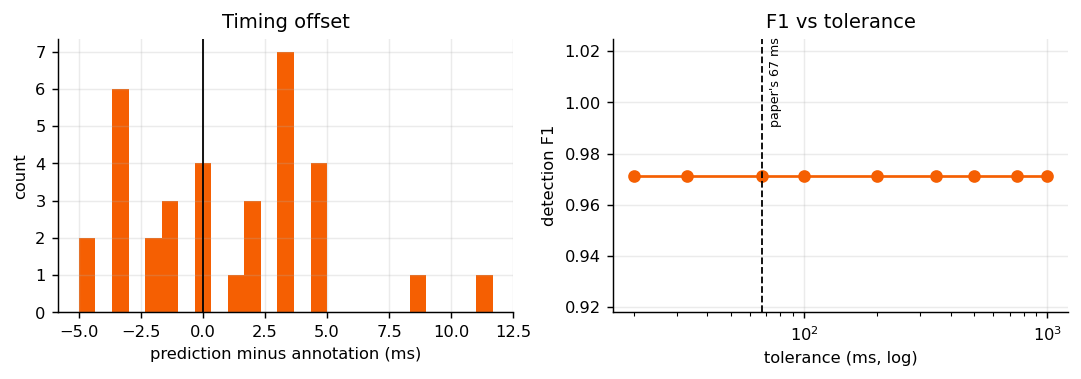


  Where this curve plateaus is the annotation's own precision.
  A working detector plateaus early; if it climbs all the way to 1 s,
  the matches are coincidences rather than the same events.


In [10]:
def match(pred_t, true_t, tol):
    used, pairs = set(), []
    for pi in np.argsort(pred_t):
        best, bd = None, tol + 1e-9
        for ti, tt_ in enumerate(true_t):
            if ti in used:
                continue
            dd = abs(pred_t[pi] - tt_)
            if dd < bd:
                best, bd = ti, dd
        if best is not None:
            used.add(best); pairs.append((pi, best))
    return pairs

pt, tt = pred.timestamp_s.values, gt.t.values
pairs = match(pt, tt, TOL_S)
TP = len(pairs); FP = len(pt) - TP; FN = len(tt) - TP
P_, R_ = TP/max(TP+FP, 1), TP/max(TP+FN, 1)
F1 = 2*P_*R_/max(P_+R_, 1e-9)

print("=" * 74)
print(f"DETECTION  at +/- {TOL_S*1000:.0f} ms"
      + ("" if PRECISE else "   (annotation-limited)"))
print("=" * 74)
print(f"  TP {TP}   FP {FP}   FN {FN}")
print(f"  precision {P_:.3f}   recall {R_:.3f}   F1 {F1:.3f}")
print(f"  (paper, cross-validated at 67 ms: 0.879)")

offs = np.array([pt[pi] - tt[ti] for pi, ti in pairs])
print(f"\n  offset  mean {offs.mean()*1000:+.0f} ms   sd {offs.std()*1000:.0f} ms"
      f"   median |err| {np.median(abs(offs))*1000:.0f} ms")
if abs(offs.mean()) > 0.03:
    print(f"  a systematic {offs.mean()*1000:+.0f} ms bias suggests the annotation")
    print(f"  marks a different moment than contact (bounce, or backswing start).")

if len(pairs):
    yt = np.array([C2I[gt.shot_class.iloc[ti]] for _, ti in pairs])
    yp = np.array([C2I[pred.shot_class.iloc[pi]] for pi, _ in pairs])
    print("\n" + "=" * 74)
    print(f"CLASSIFICATION  on {len(pairs)} matched shots")
    print("=" * 74)
    print(classification_report(yt, yp, target_names=CLASSES, digits=3,
                                zero_division=0, labels=range(4)))
    cm = confusion_matrix(yt, yp, labels=range(4))
    cmdf = pd.DataFrame(cm, index=CLASSES, columns=CLASSES)
    cmdf["recall"] = (np.diag(cm)/np.maximum(cm.sum(1), 1)).round(3)
    print(cmdf.to_string())

    side_ok = np.mean([pred.player.iloc[pi] == gt.player.iloc[ti]
                       for pi, ti in pairs])
    print(f"\n  side attribution {side_ok:.3f}   (paper: 0.994)")
    if side_ok < 0.7:
        print("  !! below 0.7 means the matched pairs are probably not the same")
        print("     events. Re-check alignment before believing anything above.")

fig, ax = plt.subplots(1, 2, figsize=(8.2, 2.8))
ax[0].hist(offs*1000, bins=25, color="#f55f02")
ax[0].axvline(0, c="black", lw=1)
ax[0].set_xlabel("prediction minus annotation (ms)"); ax[0].set_ylabel("count")
ax[0].set_title("Timing offset")

tols = np.array([0.02, 0.033, 0.067, 0.1, 0.2, 0.35, 0.5, 0.75, 1.0])
f1s = []
for t_ in tols:
    pr = match(pt, tt, t_); tp = len(pr)
    p_, r_ = tp/max(len(pt), 1), tp/max(len(tt), 1)
    f1s.append(2*p_*r_/max(p_+r_, 1e-9))
ax[1].plot(tols*1000, f1s, "o-", color="#f55f02")
ax[1].axvline(67, ls="--", c="black", lw=1)
ax[1].text(72, min(f1s)+0.02, "paper's 67 ms", fontsize=7, rotation=90)
ax[1].set_xscale("log"); ax[1].set_xlabel("tolerance (ms, log)")
ax[1].set_ylabel("detection F1"); ax[1].set_title("F1 vs tolerance")
plt.show()

print("\n  Where this curve plateaus is the annotation's own precision.")
print("  A working detector plateaus early; if it climbs all the way to 1 s,")
print("  the matches are coincidences rather than the same events.")

## 9 · Rally structure

RALLIES
  annotated 8   detected 8   error +0.0%
  mean length  annotated 4.4   detected 4.4

  boundary F1 (+/-1 s) 1.000   (paper: 0.769)


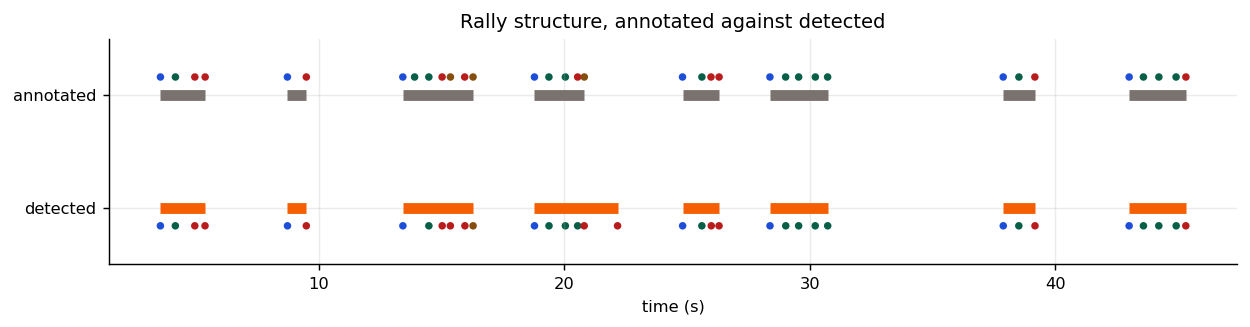

In [11]:
pred_r = pred.rally_id.nunique()
true_r = gt.rally.nunique()
print("=" * 74)
print("RALLIES")
print("=" * 74)
print(f"  annotated {true_r}   detected {pred_r}   "
      f"error {(pred_r-true_r)/true_r:+.1%}")
print(f"  mean length  annotated {len(gt)/true_r:.1f}   "
      f"detected {len(pred)/max(pred_r,1):.1f}")

tb = gt.groupby("rally").t.min().values[1:]
pb = pred.groupby("rally_id").timestamp_s.min().values[1:]
if len(tb) and len(pb):
    bp = match(pb, tb, 1.0)
    bP, bR = len(bp)/max(len(pb), 1), len(bp)/max(len(tb), 1)
    print(f"\n  boundary F1 (+/-1 s) {2*bP*bR/max(bP+bR,1e-9):.3f}   (paper: 0.769)")

fig, ax = plt.subplots(figsize=(9.5, 2.4))
for r in gt.rally.unique():
    g = gt[gt.rally == r]
    ax.plot([g.t.min(), g.t.max()], [1, 1], lw=6, solid_capstyle="butt",
            color="#7a726e")
for r in pred.rally_id.unique():
    g = pred[pred.rally_id == r]
    ax.plot([g.timestamp_s.min(), g.timestamp_s.max()], [0, 0], lw=6,
            solid_capstyle="butt", color="#f55f02")
ax.scatter(gt.t, np.ones(len(gt)) + 0.16, s=10,
           c=[PAL[c] for c in gt.shot_class])
ax.scatter(pred.timestamp_s, np.zeros(len(pred)) - 0.16, s=10,
           c=[PAL[c] for c in pred.shot_class])
ax.set_yticks([0, 1]); ax.set_yticklabels(["detected", "annotated"])
ax.set_xlabel("time (s)"); ax.set_ylim(-0.5, 1.5)
ax.set_title("Rally structure, annotated against detected")
plt.show()

## 10 · Summary

In [12]:
print("=" * 74)
print("UNSEEN FOOTAGE SUMMARY")
print("=" * 74)
print(f"  clip                 {DUR/60:.1f} min at {SRC_FPS:.0f} fps"
      + ("" if abs(SCALE-1) < 0.01 else f", resampled to {GRID_FPS:.0f}"))
print(f"  shot count           {len(pred)} detected against {len(gt)} annotated "
      f"({(len(pred)-len(gt))/len(gt):+.1%})")
print(f"  rallies              {pred_r} against {true_r}")
if len(pairs):
    print(f"  side attribution     {side_ok:.3f}")
    print(f"  classification       macro-F1 "
          f"{f1_score(yt, yp, average='macro', zero_division=0):.3f} on matched shots")
print(f"  detection            F1 {F1:.3f} at +/- {TOL_S*1000:.0f} ms")

print(textwrap.dedent(f"""

  FOR THE PAPER

    These models never saw this video, this venue or these players, so this is
    the external check the cross-validation cannot provide.

    Detection F1 here is {'comparable to' if PRECISE else 'NOT comparable to'}
    the paper's 0.879, which is scored at 67 ms on frame-accurate labels.
    {'' if PRECISE else 'State the looser tolerance and say why.'}

    Say plainly: one clip, {len(gt)} shots, annotated by one person.
    A single external result is evidence, not a validation set."""))

UNSEEN FOOTAGE SUMMARY
  clip                 0.8 min at 60 fps, resampled to 120
  shot count           35 detected against 35 annotated (+0.0%)
  rallies              8 against 8
  side attribution     1.000
  classification       macro-F1 0.830 on matched shots
  detection            F1 0.971 at +/- 67 ms


FOR THE PAPER

  These models never saw this video, this venue or these players, so this is
  the external check the cross-validation cannot provide.

  Detection F1 here is comparable to
  the paper's 0.879, which is scored at 67 ms on frame-accurate labels.


  Say plainly: one clip, 35 shots, annotated by one person.
  A single external result is evidence, not a validation set.


In [13]:
import json
from datetime import datetime, timezone

out = BASE/"outputs/metrics"
out.mkdir(parents=True, exist_ok=True)

summary = {
    "video_id": VIDEO,
    "evaluated_at": datetime.now(timezone.utc).isoformat(),
    "source": {
        "fps": round(SRC_FPS, 3),
        "resampled_to": GRID_FPS,
        "frames": NFR,
        "duration_s": round(DUR, 3),
        "resolution": [W, H],
    },
    "ground_truth": {
        "shots": len(gt),
        "rallies": int(gt.rally.nunique()),
        "annotation_resolution_s": 0.01,
        "annotators": 1,
        "class_counts": gt.shot_class.value_counts().to_dict(),
    },
    "detection": {
        "tolerance_s": TOL_S,
        "tp": TP, "fp": FP, "fn": FN,
        "precision": round(P_, 4),
        "recall": round(R_, 4),
        "f1": round(F1, 4),
        "offset_mean_ms": round(float(offs.mean()*1000), 1),
        "offset_sd_ms": round(float(offs.std()*1000), 1),
    },
    "shot_count": {
        "detected": len(pred),
        "annotated": len(gt),
        "error_pct": round((len(pred)-len(gt))/len(gt)*100, 2),
    },
    "rallies": {"detected": int(pred_r), "annotated": int(true_r)},
    "side_attribution": round(float(side_ok), 4),
    "classification": {
        "matched_shots": len(pairs),
        "macro_f1": round(float(f1_score(yt, yp, average="macro",
                                         zero_division=0)), 4),
        "per_class": classification_report(yt, yp, target_names=CLASSES,
                                           output_dict=True, zero_division=0,
                                           labels=range(4)),
        "confusion": confusion_matrix(yt, yp, labels=range(4)).tolist(),
    },
}

p = out/f"external_{VIDEO}.json"
p.write_text(json.dumps(summary, indent=2))
print(f"-> {p}")

# the per-shot pairing, so any number above can be re-derived
rows = [dict(gt_t=float(gt.t.iloc[ti]), pred_t=float(pt[pi]),
             offset_ms=round(float((pt[pi]-gt.t.iloc[ti])*1000), 1),
             gt_class=gt.shot_class.iloc[ti], pred_class=pred.shot_class.iloc[pi],
             gt_player=gt.player.iloc[ti], pred_player=pred.player.iloc[pi],
             conf=float(pred.class_confidence.iloc[pi]))
        for pi, ti in sorted(pairs, key=lambda x: x[1])]
pd.DataFrame(rows).to_csv(out/f"external_{VIDEO}_pairs.csv", index=False)
print(f"-> {out/f'external_{VIDEO}_pairs.csv'}  ({len(rows)} matched pairs)")

-> /content/drive/MyDrive/tt_coach/outputs/metrics/external_test_match2.json
-> /content/drive/MyDrive/tt_coach/outputs/metrics/external_test_match2_pairs.csv  (34 matched pairs)


---
## If the alignment gate fails

The ratio in Section 6 names the problem.

**Near 0.5 or 2.0** — a frame-rate assumption is still wrong. Check that
`SRC_FPS` in Section 1 matches `ffprobe`, and that Section 4 reported a
resample.

**Near 1 but offsets scattered** — the annotation was made on a different cut.
Confirm the file in `raw/external/` is byte-identical to the one annotated.

**Side attribution below 0.7** — the matched pairs are not the same events. No
number below that point means anything.
